# Lecture 02: Gradient Descent on Potential Energy Surfaces

**Machine Learning Applications in Physics (PHYG004)** — Sogang University, 2026 Spring

---

## Overview

In the lecture, we saw that **ML training** and **physical optimization** share identical mathematical structure:

| Physics | ML |
|---|---|
| Potential energy $V(\mathbf{x})$ | Loss function $\mathcal{L}(\theta)$ |
| Position $\mathbf{x}$ | Parameters $\theta$ (weights) |
| Force $\mathbf{F} = -\nabla V$ | Negative gradient $-\nabla_\theta \mathcal{L}$ |
| Energy minimization | Loss minimization |

In this notebook, we will **experience this connection directly** by running gradient descent on physical potential energy surfaces using JAX.

## Learning Objectives

- Implement gradient descent from scratch using `jax.grad`
- Visualize optimization trajectories on 1D and 2D potential surfaces
- Understand the effects of initial position, learning rate, and local minima
- Connect potential energy optimization to neural network training

In [1]:
# Install dependencies (run this on Google Colab)
!pip install -q jax jaxlib matplotlib

In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

print(f"JAX version: {jax.__version__}")
print(f"Backend: {jax.default_backend()}")

JAX version: 0.9.1
Backend: cpu


---
## 1. 1D Double-Well Potential

We start with the classic double-well potential:

$$V(x) = (x^2 - 1)^2$$

This potential has:
- Two **minima** at $x = \pm 1$ (ground states)
- One **local maximum** (unstable equilibrium) at $x = 0$
- A **barrier** separating the two wells

This is analogous to a loss function with multiple local minima — a key challenge in neural network training.

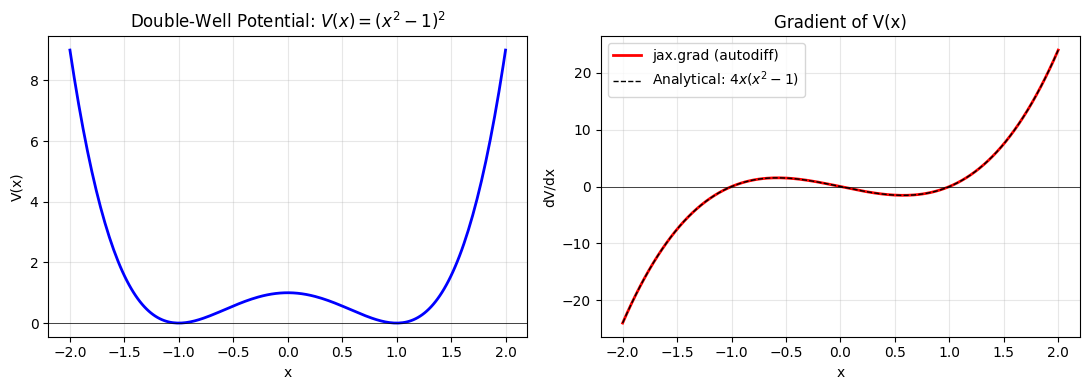

jax.grad gives exact derivatives — no finite differences needed!


In [4]:
# Define the double-well potential
def V_1d(x: float) -> float:
    """Double-well potential: V(x) = (x^2 - 1)^2"""
    return (x**2 - 1)**2

# Compute the gradient using jax.grad — this is the "force" (with a minus sign)
dV_dx = jax.grad(V_1d)

# Plot the potential and its gradient
x = jnp.linspace(-2.0, 2.0, 200)
V_vals = jax.vmap(V_1d)(x)
dV_vals = jax.vmap(dV_dx)(x)

# Compare with analytical derivative: dV/dx = 4x(x^2 - 1)
dV_analytical = 4 * x * (x**2 - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(x, V_vals, 'b-', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('V(x)')
ax1.set_title('Double-Well Potential: $V(x) = (x^2 - 1)^2$')
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.grid(True, alpha=0.3)

ax2.plot(x, dV_vals, 'r-', linewidth=2, label='jax.grad (autodiff)')
ax2.plot(x, dV_analytical, 'k--', linewidth=1, label='Analytical: $4x(x^2-1)$')
ax2.set_xlabel('x')
ax2.set_ylabel('dV/dx')
ax2.set_title('Gradient of V(x)')
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("jax.grad gives exact derivatives — no finite differences needed!")

In [5]:
def gradient_descent_1d(V_fn, x0: float, lr: float = 0.05, n_steps: int = 80):
    """Run gradient descent on a 1D potential.

    Args:
        V_fn: potential energy function V(x) -> scalar
        x0: initial position
        lr: learning rate (step size)
        n_steps: number of gradient descent steps

    Returns:
        trajectory: array of positions at each step
        energies: array of V(x) at each step
    """
    grad_fn = jax.grad(V_fn)

    trajectory = [x0]
    energies = [V_fn(x0)]

    x = x0
    for _ in range(n_steps):
        g = grad_fn(x)
        x = x - lr * g  # gradient descent update
        trajectory.append(x)
        energies.append(V_fn(x))

    return jnp.array(trajectory), jnp.array(energies)

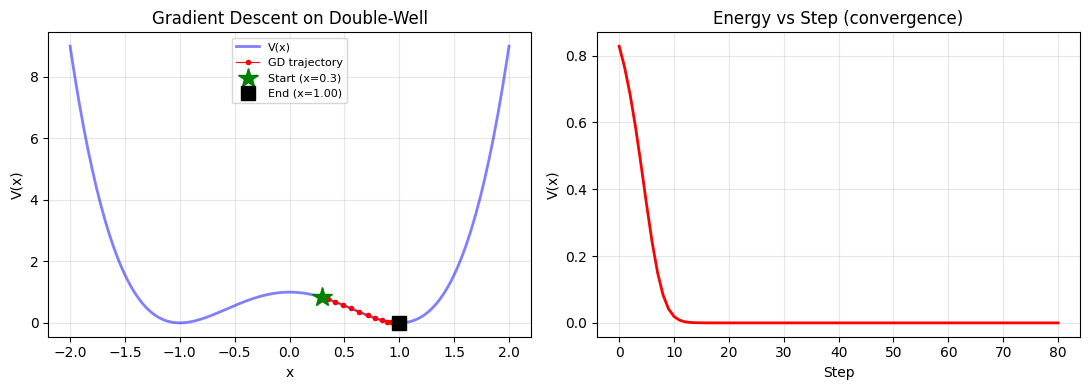

Starting position: x = 0.300, V = 0.8281
Final position:    x = 1.000, V = 0.000000


In [6]:
# Run gradient descent from x0 = 0.3
traj, energies = gradient_descent_1d(V_1d, x0=0.3, lr=0.05, n_steps=80)

# Visualize the trajectory on the potential
x_plot = jnp.linspace(-2.0, 2.0, 200)
V_plot = jax.vmap(V_1d)(x_plot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: trajectory on potential surface
ax1.plot(x_plot, V_plot, 'b-', linewidth=2, alpha=0.5, label='V(x)')
ax1.plot(traj, jax.vmap(V_1d)(traj), 'ro-', markersize=3, linewidth=0.8, label='GD trajectory')
ax1.plot(traj[0], V_1d(traj[0]), 'g*', markersize=15, label=f'Start (x={traj[0]:.1f})')
ax1.plot(traj[-1], V_1d(traj[-1]), 'ks', markersize=10, label=f'End (x={traj[-1]:.2f})')
ax1.set_xlabel('x')
ax1.set_ylabel('V(x)')
ax1.set_title('Gradient Descent on Double-Well')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: energy vs step
ax2.plot(energies, 'r-', linewidth=2)
ax2.set_xlabel('Step')
ax2.set_ylabel('V(x)')
ax2.set_title('Energy vs Step (convergence)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Starting position: x = {traj[0]:.3f}, V = {energies[0]:.4f}")
print(f"Final position:    x = {traj[-1]:.3f}, V = {energies[-1]:.6f}")

### Experiment 1: Effect of Initial Position

The initial position determines **which minimum** gradient descent converges to. This is exactly the local minima problem in neural network training — different random initializations can lead to different solutions.

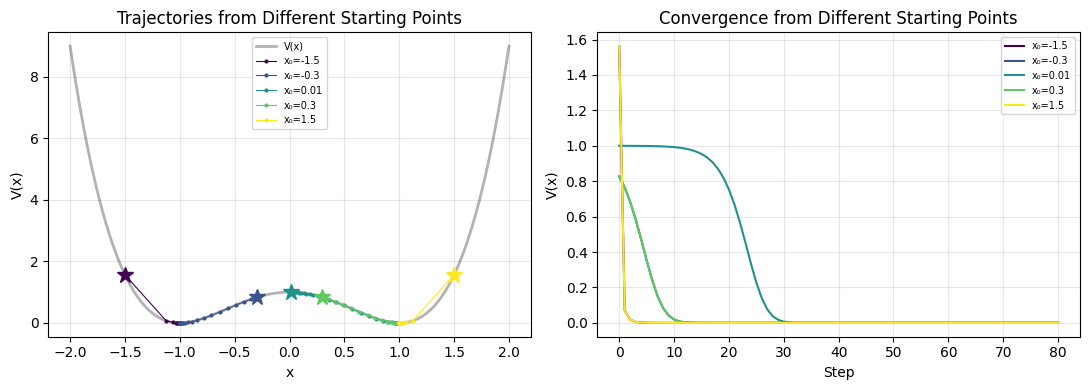

Key observations:
  - x₀ < 0 → converges to left minimum (x = -1)
  - x₀ > 0 → converges to right minimum (x = +1)
  - x₀ ≈ 0 → unstable! Tiny perturbation determines the outcome


In [7]:
# Try multiple initial positions
initial_positions = [-1.5, -0.3, 0.01, 0.3, 1.5]
colors = plt.cm.viridis(jnp.linspace(0, 1, len(initial_positions)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Plot potential
ax1.plot(x_plot, V_plot, 'k-', linewidth=2, alpha=0.3, label='V(x)')

for x0, color in zip(initial_positions, colors):
    traj, energies = gradient_descent_1d(V_1d, x0=x0, lr=0.05, n_steps=80)
    ax1.plot(traj, jax.vmap(V_1d)(traj), 'o-', color=color, markersize=2,
             linewidth=0.8, label=f'x₀={x0}')
    ax1.plot(traj[0], V_1d(traj[0]), '*', color=color, markersize=12)
    ax2.plot(energies, '-', color=color, linewidth=1.5, label=f'x₀={x0}')

ax1.set_xlabel('x')
ax1.set_ylabel('V(x)')
ax1.set_title('Trajectories from Different Starting Points')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Step')
ax2.set_ylabel('V(x)')
ax2.set_title('Convergence from Different Starting Points')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - x₀ < 0 → converges to left minimum (x = -1)")
print("  - x₀ > 0 → converges to right minimum (x = +1)")
print("  - x₀ ≈ 0 → unstable! Tiny perturbation determines the outcome")

### Experiment 2: Effect of Learning Rate

The learning rate $\eta$ controls the step size. Too small → slow convergence. Too large → oscillation or divergence. This is the most important hyperparameter in neural network training.

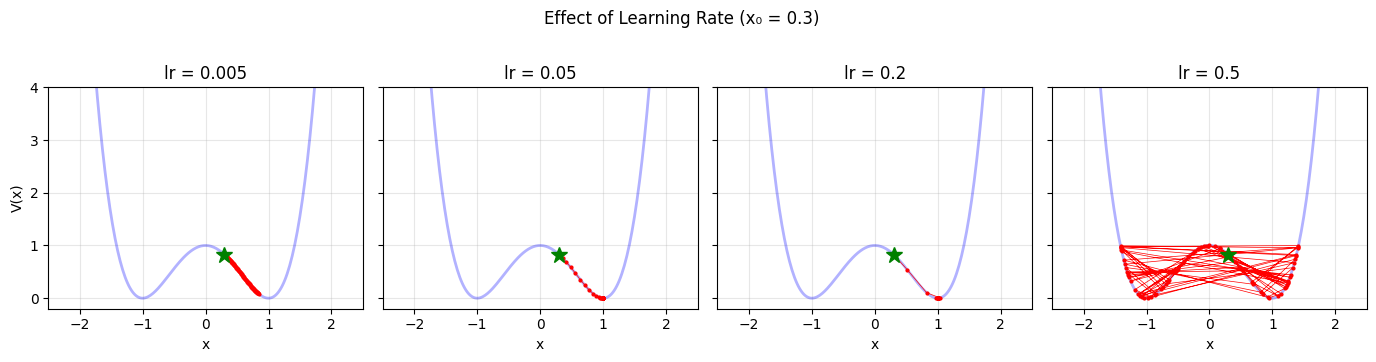

Observations:
  lr = 0.005 → Very slow convergence (barely moves)
  lr = 0.05  → Good convergence to nearby minimum
  lr = 0.2   → Fast but oscillates before settling
  lr = 0.5   → May overshoot and jump between wells!


In [8]:
# Compare different learning rates from the same starting point
learning_rates = [0.005, 0.05, 0.2, 0.5]
x0 = 0.3

fig, axes = plt.subplots(1, len(learning_rates), figsize=(14, 3.5), sharey=True)

for ax, lr in zip(axes, learning_rates):
    traj, energies = gradient_descent_1d(V_1d, x0=x0, lr=lr, n_steps=80)

    ax.plot(x_plot, V_plot, 'b-', linewidth=2, alpha=0.3)
    ax.plot(traj, jax.vmap(V_1d)(traj), 'ro-', markersize=2, linewidth=0.5)
    ax.plot(traj[0], V_1d(traj[0]), 'g*', markersize=12)
    ax.set_xlabel('x')
    ax.set_title(f'lr = {lr}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-0.2, 4.0)

axes[0].set_ylabel('V(x)')
plt.suptitle(f'Effect of Learning Rate (x₀ = {x0})', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Observations:")
print("  lr = 0.005 → Very slow convergence (barely moves)")
print("  lr = 0.05  → Good convergence to nearby minimum")
print("  lr = 0.2   → Fast but oscillates before settling")
print("  lr = 0.5   → May overshoot and jump between wells!")

---
## 2. 2D Potential Energy Surface

Now let's move to 2D, where we can visualize trajectories on a contour map. We use the **Muller-Brown potential**, a classic benchmark in computational chemistry with three minima and two saddle points:

$$V(x, y) = \sum_{k=1}^{4} A_k \exp\!\big[a_k(x - x_k^0)^2 + b_k(x - x_k^0)(y - y_k^0) + c_k(y - y_k^0)^2\big]$$

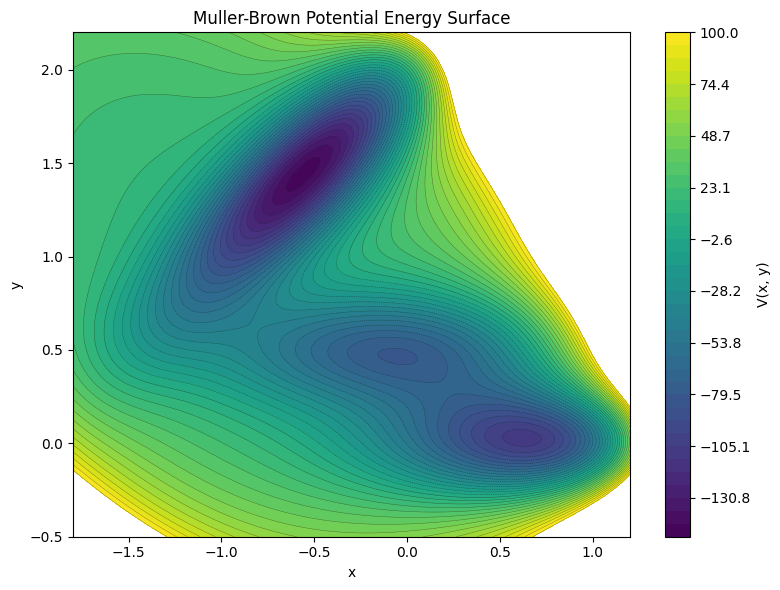

This surface has 3 minima and 2 saddle points —
a realistic toy model for optimization landscapes.


In [9]:
# Muller-Brown potential — a classic test surface in computational chemistry
def V_2d(pos: jnp.ndarray) -> float:
    """Muller-Brown potential. pos = [x, y]."""
    x, y = pos[0], pos[1]

    A  = jnp.array([-200.0, -100.0, -170.0, 15.0])
    a  = jnp.array([  -1.0,   -1.0,   -6.5,  0.7])
    b  = jnp.array([   0.0,    0.0,   11.0,  0.6])
    c  = jnp.array([ -10.0,  -10.0,   -6.5,  0.7])
    x0 = jnp.array([   1.0,    0.0,   -0.5,  -1.0])
    y0 = jnp.array([   0.0,    0.5,    1.5,   1.0])

    return jnp.sum(
        A * jnp.exp(a * (x - x0)**2 + b * (x - x0) * (y - y0) + c * (y - y0)**2)
    )

# Create a grid and evaluate the potential
nx, ny = 200, 200
x_grid = jnp.linspace(-1.8, 1.2, nx)
y_grid = jnp.linspace(-0.5, 2.2, ny)
X, Y = jnp.meshgrid(x_grid, y_grid)
positions = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
Z = jax.vmap(V_2d)(positions).reshape(ny, nx)

# Plot the potential energy surface
fig, ax = plt.subplots(figsize=(8, 6))
levels = jnp.linspace(-150, 100, 40)
cs = ax.contourf(X, Y, Z, levels=levels, cmap='viridis')
ax.contour(X, Y, Z, levels=levels, colors='k', linewidths=0.3, alpha=0.5)
plt.colorbar(cs, ax=ax, label='V(x, y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Muller-Brown Potential Energy Surface')
plt.tight_layout()
plt.show()

print("This surface has 3 minima and 2 saddle points —")
print("a realistic toy model for optimization landscapes.")

In [10]:
def gradient_descent_2d(V_fn, pos0: jnp.ndarray, lr: float = 0.0001,
                        n_steps: int = 300):
    """Run gradient descent on a 2D potential.

    Args:
        V_fn: potential energy function V([x, y]) -> scalar
        pos0: initial position [x0, y0]
        lr: learning rate
        n_steps: number of steps

    Returns:
        trajectory: (n_steps+1, 2) array of positions
        energies: (n_steps+1,) array of V values
    """
    grad_fn = jax.grad(V_fn)

    trajectory = [pos0]
    energies = [V_fn(pos0)]

    pos = pos0
    for _ in range(n_steps):
        g = grad_fn(pos)
        pos = pos - lr * g
        trajectory.append(pos)
        energies.append(V_fn(pos))

    return jnp.array(trajectory), jnp.array(energies)

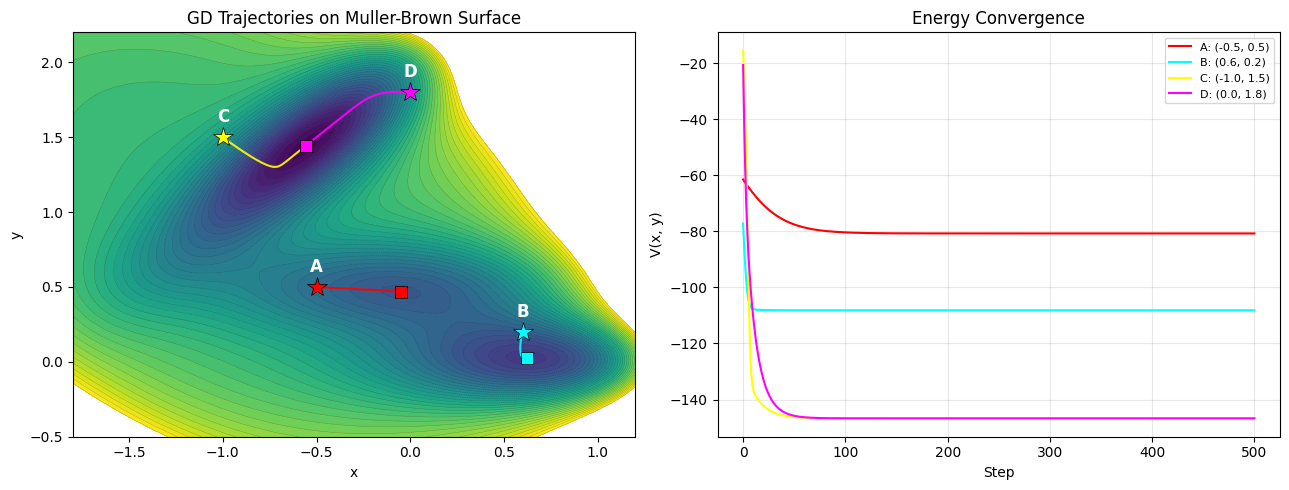

Different starting points converge to different local minima.
The global minimum is not always found — this is the local minima problem.


In [11]:
# Run gradient descent from several starting points
start_points = [
    jnp.array([-0.5, 0.5]),
    jnp.array([0.6, 0.2]),
    jnp.array([-1.0, 1.5]),
    jnp.array([0.0, 1.8]),
]
labels = ['A', 'B', 'C', 'D']
colors = ['red', 'cyan', 'yellow', 'magenta']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: trajectories on contour plot
levels = jnp.linspace(-150, 100, 40)
ax1.contourf(X, Y, Z, levels=levels, cmap='viridis')
ax1.contour(X, Y, Z, levels=levels, colors='k', linewidths=0.3, alpha=0.3)

for pos0, label, color in zip(start_points, labels, colors):
    traj, energies = gradient_descent_2d(V_2d, pos0, lr=0.0001, n_steps=500)
    ax1.plot(traj[:, 0], traj[:, 1], '-', color=color, linewidth=1.5, alpha=0.9)
    ax1.plot(traj[0, 0], traj[0, 1], '*', color=color, markersize=15,
             markeredgecolor='k', markeredgewidth=0.5)
    ax1.plot(traj[-1, 0], traj[-1, 1], 's', color=color, markersize=8,
             markeredgecolor='k', markeredgewidth=0.5)
    ax1.annotate(label, (traj[0, 0], traj[0, 1]), fontsize=12, fontweight='bold',
                 color='white', ha='center', va='bottom',
                 xytext=(0, 8), textcoords='offset points')

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('GD Trajectories on Muller-Brown Surface')

# Right: energy convergence
for pos0, label, color in zip(start_points, labels, colors):
    traj, energies = gradient_descent_2d(V_2d, pos0, lr=0.0001, n_steps=500)
    ax2.plot(energies, '-', color=color, linewidth=1.5, label=f'{label}: ({pos0[0]:.1f}, {pos0[1]:.1f})')

ax2.set_xlabel('Step')
ax2.set_ylabel('V(x, y)')
ax2.set_title('Energy Convergence')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Different starting points converge to different local minima.")
print("The global minimum is not always found — this is the local minima problem.")

---
## 3. Connection to Neural Network Training

Everything we just did maps directly to neural network training:

| This notebook | Neural network training |
|---|---|
| Potential $V(x)$ | Loss function $\mathcal{L}(\theta)$ |
| Position $x$ | Network weights $\theta$ |
| Force $F = -\nabla V$ | Negative loss gradient $-\nabla_\theta \mathcal{L}$ |
| `lr` (learning rate) | Same — most important hyperparameter |
| Local minimum | Suboptimal trained model |
| Initial position | Random weight initialization |
| Trajectory | Training history |

### Key takeaways

1. **Gradient descent is gradient descent** — whether on a physical potential or a loss landscape
2. **Local minima** are unavoidable in non-convex landscapes (both physics and ML)
3. **Learning rate** must be tuned: too small → slow, too large → divergence
4. **Initialization matters** — different starting points lead to different solutions
5. **`jax.grad`** makes this trivial — no need to derive gradients by hand

In the next lecture, we will use these same ideas to train actual neural networks!

---
## Optional Exercises

Try these on your own:

1. **Different potential**: Define $V(x) = x^4 - 3x^2 + x$ and run gradient descent. How many minima does it have?

2. **Momentum**: Modify `gradient_descent_1d` to include momentum:
   $$v_{t+1} = \mu \, v_t - \eta \nabla V(x_t), \qquad x_{t+1} = x_t + v_{t+1}$$
   Try $\mu = 0.9$. Does momentum help escape shallow local minima?

3. **Saddle points**: Start at a saddle point of the Muller-Brown surface (approximately $(-0.82, 0.62)$). What happens? What does this tell us about saddle points in high-dimensional optimization?

4. **Gradient field**: Plot the gradient vector field $-\nabla V(x, y)$ on the 2D surface using `plt.quiver`. This shows the "force field" that drives gradient descent.